# Automobile Price Data Analysis

## Project Overview
This project explores factors that influence automobile prices using statistical analysis, data visualization, correlation analysis, and ANOVA testing. The objective is to identify the most significant numerical and categorical features associated with vehicle pricing.

## Objectives
- Understand the structure of the automobile dataset.
- Explore relationships between vehicle characteristics and price.
- Identify significant predictors of automobile prices.
- Use statistical methods to validate relationships.
- Prepare insights for future predictive modeling.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'C:\Users\KHENNYG\Downloads\Automobile_dataset.csv')

In [3]:
df.head()

,symboling,normalized_losses,make,num_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,...,horsepower,peak_rpm,city_L_100km,highway_L_100km,price,horsepower-binned,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
0,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,111,5000.0,11.190476,8.703704,13495,Low,False,True,True,False
1,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,111,5000.0,11.190476,8.703704,16500,Low,False,True,True,False
2,1,122,alfa-romero,two,hatchback,rwd,front,94.5,0.822681,0.909722,...,154,5000.0,12.368421,9.038462,16500,Medium,False,True,True,False
3,2,164,audi,four,sedan,fwd,front,99.8,0.848630,0.919444,...,102,5500.0,9.791667,7.833333,13950,Low,False,True,True,False
4,2,164,audi,four,sedan,4wd,front,99.4,0.848630,0.922222,...,115,5500.0,13.055556,10.681818,17450,Low,False,True,True,False


In [4]:
df.head()

,symboling,normalized_losses,make,num_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,...,horsepower,peak_rpm,city_L_100km,highway_L_100km,price,horsepower-binned,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
0,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,111,5000.0,11.190476,8.703704,13495,Low,False,True,True,False
1,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,111,5000.0,11.190476,8.703704,16500,Low,False,True,True,False
2,1,122,alfa-romero,two,hatchback,rwd,front,94.5,0.822681,0.909722,...,154,5000.0,12.368421,9.038462,16500,Medium,False,True,True,False
3,2,164,audi,four,sedan,fwd,front,99.8,0.848630,0.919444,...,102,5500.0,9.791667,7.833333,13950,Low,False,True,True,False
4,2,164,audi,four,sedan,4wd,front,99.4,0.848630,0.922222,...,115,5500.0,13.055556,10.681818,17450,Low,False,True,True,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized_losses  201 non-null    int64  
 2   make               201 non-null    object 
 3   num_doors          201 non-null    object 
 4   body_style         201 non-null    object 
 5   drive_wheels       201 non-null    object 
 6   engine_location    201 non-null    object 
 7   wheel_base         201 non-null    float64
 8   length             201 non-null    float64
 9   width              201 non-null    float64
 10  height             201 non-null    float64
 11  curb_weight        201 non-null    int64  
 12  engine_type        201 non-null    object 
 13  num_cylinders      201 non-null    object 
 14  engine_size        201 non-null    int64  
 15  fuel_system        201 non-null    object 
 16  bore               201 non

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [7]:
# list the data types for each column
print(df.dtypes)

symboling              int64
normalized_losses      int64
make                  object
num_doors             object
body_style            object
drive_wheels          object
engine_location       object
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type           object
num_cylinders         object
engine_size            int64
fuel_system           object
bore                 float64
stroke               float64
compression_ratio    float64
horsepower             int64
peak_rpm             float64
city_L_100km         float64
highway_L_100km      float64
price                  int64
horsepower-binned     object
fuel-type-diesel        bool
fuel-type-gas           bool
aspiration-std          bool
aspiration-turbo        bool
dtype: object


## Dataset Description

The dataset contains technical and market information for various automobiles, including engine specifications, fuel economy metrics, vehicle dimensions, and pricing information.

Target Variable:
- Price

Feature Categories:
- Engine Specifications
- Vehicle Dimensions
- Fuel Economy
- Performance Metrics
- Vehicle Configuration

### Peak RPM Data Type Verification

In [8]:
df['peak_rpm'].dtypes

dtype('float64')

### Correlation Analysis of Engine Features
Find the correlation between the following columns: bore, stroke, compression-ratio, and horsepower.

Hint: if you would like to select those columns, use the following syntax: df[['bore','stroke','compression-ratio','horsepower']]

In [9]:
df[['bore','stroke','compression_ratio','horsepower']].corr()

,bore,stroke,compression_ratio,horsepower
bore,1.000000,-0.055390,0.001260,0.566906
stroke,-0.055390,1.000000,0.187816,0.098175
compression_ratio,0.001260,0.187816,1.000000,-0.214489
horsepower,0.566906,0.098175,-0.214489,1.000000


## Continuous Numerical Variables:
### Continuous numerical variables are variables that may contain any value within some range. They can be of type "int64" or "float64". A great way to visualize these variables is by using scatterplots with fitted lines.

In order to start understanding the (linear) relationship between an individual variable and the price, we can use "regplot" which plots the scatterplot plus the fitted regression line for the data. This will be useful later on for visualizing the fit of the simple linear regression model as well.

Let's see several examples of different linear relationships:

### Positive Linear Relationship 
Let's find the scatterplot of "engine-size" and "price".

In [10]:
print(df['engine_size'].corr(df['price']))


0.8723351674455198


(0.0, 53327.89531777197)

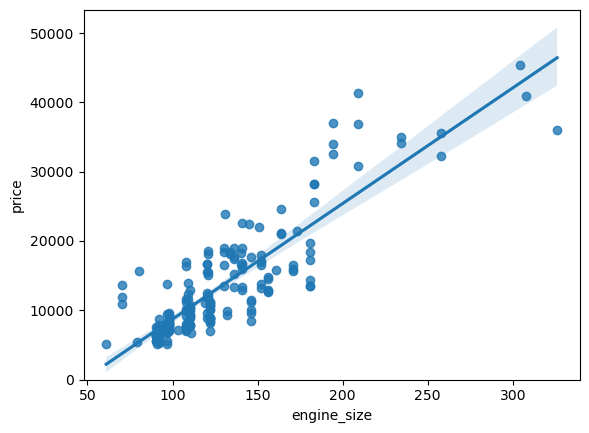

In [11]:
# Engine size as a potential predictor variable of price
sns.regplot(x="engine_size", y="price", data=df)
plt.ylim(0,)

### Key Observation

The scatterplots suggest that larger engine sizes are generally associated with higher automobile prices. The upward trend indicates a positive relationship between engine capacity and market value.

In [12]:
df[["engine_size", "price"]].corr()

,engine_size,price
engine_size,1.000000,0.872335
price,0.872335,1.000000


In [13]:
print(df['engine_size'].corr(df['price']).round(6))

0.872335


In [14]:
x = df['engine_size'].corr(df['price']).round(6)
x

np.float64(0.872335)

### Highway_L_100km  is a potential predictor variable of price. Let's find the scatterplot of "highway-mpg" and "price".

<Axes: xlabel='highway_L_100km', ylabel='price'>

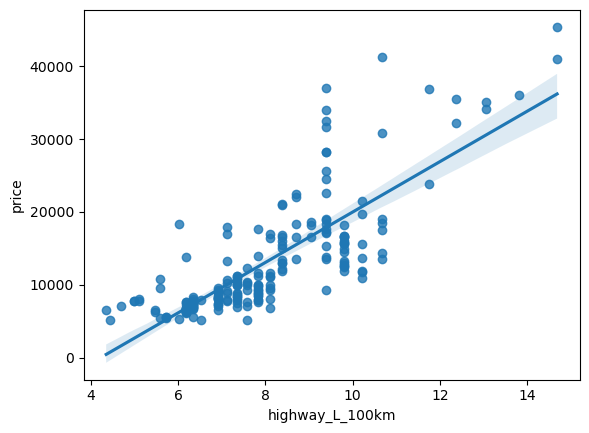

In [15]:
sns.regplot(x="highway_L_100km", y="price", data=df)

As highway_L_100km goes up, the price goes up: this indicates a positive relationship between these two variables. highway_L_100km could potentially be a predictor of price.


We can examine the correlation between 'highway_L_100km' and 'price' and see that it's approximately 0.80118.

In [16]:
#df[['highway_L_100km', 'price']].corr()
KmcorrPr = df['highway_L_100km'].corr(df['price']).round(6)
print(KmcorrPr)

0.801118


### Weak Linear Relationship

Let's see if "peak-rpm" is a predictor variable of "price".

<Axes: xlabel='peak_rpm', ylabel='price'>

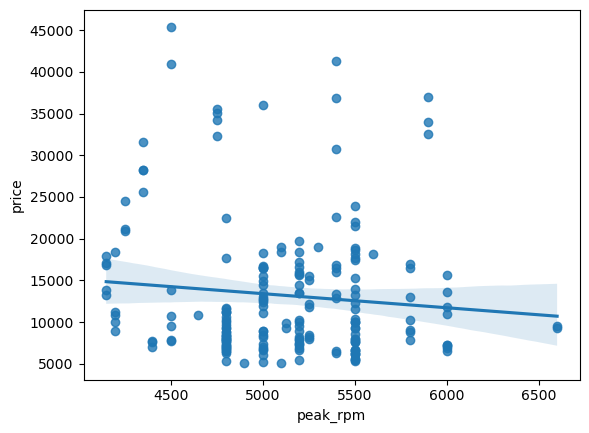

In [17]:
sns.regplot(x="peak_rpm", y="price", data=df)

##### Peak rpm does not seem like a good predictor of the price at all since the regression line is close to horizontal. Also, the data points are very scattered and far from the fitted line, showing lots of variability. Therefore, it's not a reliable variable.

We can examine the correlation between 'peak-rpm' and 'price' and see it's approximately -0.101616.

In [18]:
df[['peak_rpm','price']].corr()

,peak_rpm,price
peak_rpm,1.000000,-0.101616
price,-0.101616,1.000000


### Stroke vs Price Correlation Analysis
Find the correlation between x="stroke" and y="price".

Hint: if you would like to select those columns, use the following syntax: df[["stroke","price"]].

In [19]:
# Write your code below and press Shift+Enter to execute
df[['stroke', 'price']].corr()

,stroke,price
stroke,1.000000,0.082262
price,0.082262,1.000000


In [74]:
v = df['stroke'].corr(df['price']).round(6)
print(v)

0.082262


### Interpretation of Stroke and Price Relationship
Given the correlation results between "price" and "stroke", do you expect a linear relationship?

Verify your results using the function "regplot()".

<Axes: xlabel='stroke', ylabel='price'>

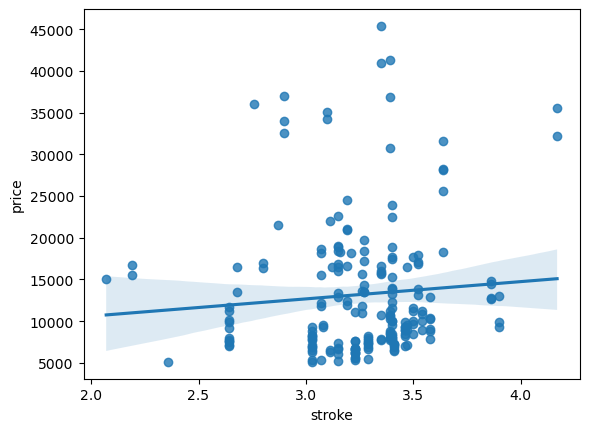

In [20]:
sns.regplot(x = 'stroke', y = 'price', data = df)

## Correlation Analysis Summary

Preliminary correlation analysis indicates that engine size, horsepower, width, and curb weight exhibit stronger relationships with automobile price than many other numerical variables. These features are likely to be important predictors in future pricing models.

#### Categorical Variables
These are variables that describe a 'characteristic' of a data unit, and are selected from a small group of categories. The categorical variables can have the type "object" or "int64". A good way to visualize categorical variables is by using boxplots.

#### Numerical variables - quantitative e.g. price of a product...
#### Categorical variables - qualitative e.g. colors, grade
Let's look at the relationship between "body-style" and "price".

<Axes: xlabel='body_style', ylabel='price'>

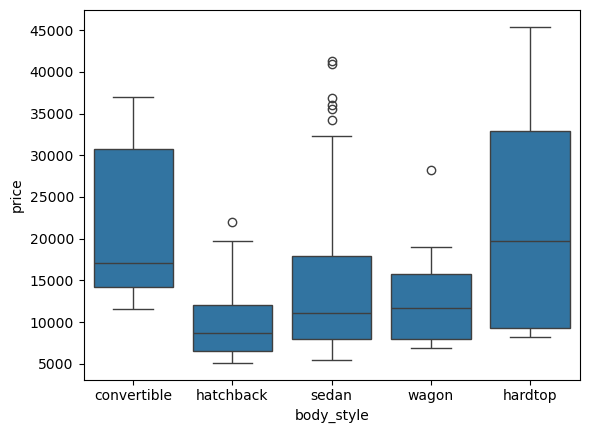

In [21]:
sns.boxplot(x="body_style", y="price", data=df)

We see that the distributions of price between the different body-style categories have a significant overlap, so body-style would not be a good predictor of price. Let's examine engine "engine-location" and "price":

<Axes: xlabel='engine_location', ylabel='price'>

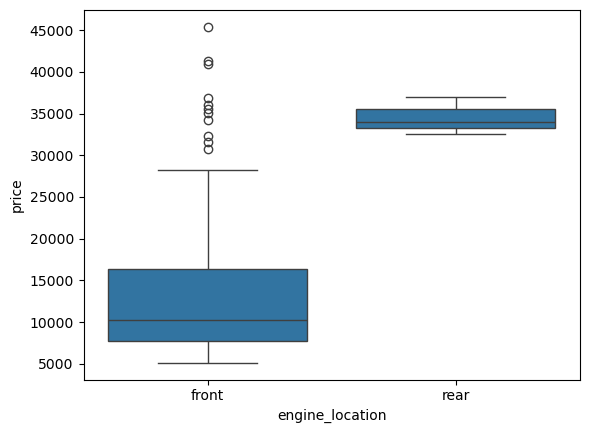

In [22]:
sns.boxplot(x="engine_location", y="price", data=df)

Here we see that the distribution of price between these two engine-location categories, front and rear, are distinct enough to take engine-location as a potential good predictor of price.

Let's examine "drive-wheels" and "price".

<Axes: xlabel='drive_wheels', ylabel='price'>

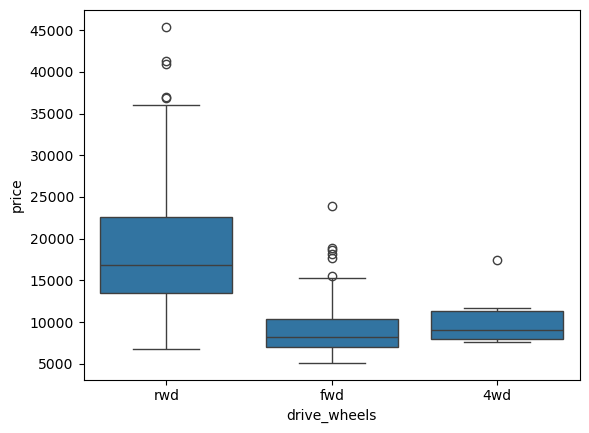

In [23]:
# drive-wheels and Price
sns.boxplot(x="drive_wheels", y="price", data=df)

Here we see that the distribution of price between the different drive-wheels categories differs. As such, drive-wheels could potentially be a predictor of price.

### 3. Descriptive Statistical Analysis
Let's first take a look at the variables by utilizing a description method.

The describe function automatically computes basic statistics for all continuous variables. Any NaN values are automatically skipped in these statistics.

This will show:

the count of that variable
the mean
the standard deviation (std)
the minimum value
the IQR (Interquartile Range: 25%, 50% and 75%)
the maximum value








We can apply the method "describe" as follows:

In [24]:
df.describe() # This only works on Numerical Variables 
#df.describe(include = 'all')
# numerical variable - quantitative

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_L_100km,highway_L_100km,price
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,0.899108,2555.666667,126.875622,3.330697,3.256965,10.164279,103.402985,5117.665373,9.944145,8.044957,13207.129353
std,1.254802,31.99625,6.066366,0.059213,0.029187,0.040933,517.296727,41.546834,0.268072,0.316048,4.004965,37.365650,478.113805,2.534599,1.840739,7947.066342
min,-2.000000,65.00000,86.600000,0.678039,0.837500,0.799331,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,4.795918,4.351852,5118.000000
25%,0.000000,101.00000,94.500000,0.801538,0.890278,0.869565,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,7.833333,6.911765,7775.000000
50%,1.000000,122.00000,97.000000,0.832292,0.909722,0.904682,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.370000,9.791667,7.833333,10295.000000
75%,2.000000,137.00000,102.400000,0.881788,0.925000,0.928094,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,12.368421,9.400000,16500.000000
max,3.000000,256.00000,120.900000,1.000000,1.000000,1.000000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,18.076923,14.687500,45400.000000


The default setting of "describe" skips variables of type object. We can apply the method "describe" on the variables of type 'object' as follows:

In [25]:
df.describe(include=['object']) #categorical
#df.describe() # numerical
#df.describe(include= 'all') #both
 #  categorical variable - qualitative

,make,num_doors,body_style,drive_wheels,engine_location,engine_type,num_cylinders,fuel_system,horsepower-binned
count,201,201,201,201,201,201,201,201,201
unique,22,2,5,3,2,6,7,8,3
top,toyota,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,115,94,118,198,145,157,92,153


In [75]:
df.describe(include = 'all')

,symboling,normalized_losses,make,num_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,...,horsepower,peak_rpm,city_L_100km,highway_L_100km,price,horsepower-binned,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
count,201.000000,201.00000,201,201,201,201,201,201.000000,201.000000,201.000000,...,201.000000,201.000000,201.000000,201.000000,201.000000,201,201,201,201,201
unique,NaN,NaN,22,2,5,3,2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3,2,2,2,2
top,NaN,NaN,toyota,four,sedan,fwd,front,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Low,False,True,True,False
freq,NaN,NaN,32,115,94,118,198,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,153,181,181,165,165
mean,0.840796,122.00000,NaN,NaN,NaN,NaN,NaN,98.797015,0.837102,0.915126,...,103.402985,5117.665373,9.944145,8.044957,13207.129353,NaN,NaN,NaN,NaN,NaN
std,1.254802,31.99625,NaN,NaN,NaN,NaN,NaN,6.066366,0.059213,0.029187,...,37.365650,478.113805,2.534599,1.840739,7947.066342,NaN,NaN,NaN,NaN,NaN
min,-2.000000,65.00000,NaN,NaN,NaN,NaN,NaN,86.600000,0.678039,0.837500,...,48.000000,4150.000000,4.795918,4.351852,5118.000000,NaN,NaN,NaN,NaN,NaN
25%,0.000000,101.00000,NaN,NaN,NaN,NaN,NaN,94.500000,0.801538,0.890278,...,70.000000,4800.000000,7.833333,6.911765,7775.000000,NaN,NaN,NaN,NaN,NaN
50%,1.000000,122.00000,NaN,NaN,NaN,NaN,NaN,97.000000,0.832292,0.909722,...,95.000000,5125.370000,9.791667,7.833333,10295.000000,NaN,NaN,NaN,NaN,NaN
75%,2.000000,137.00000,NaN,NaN,NaN,NaN,NaN,102.400000,0.881788,0.925000,...,116.000000,5500.000000,12.368421,9.400000,16500.000000,NaN,NaN,NaN,NaN,NaN


### Value Counts
Value counts is a good way of understanding how many units of each characteristic/variable we have. We can apply the "value_counts" method on the column "drive-wheels". Don’t forget the method "value_counts" only works on pandas series, not pandas dataframes. As a result, we only include one bracket df['drive-wheels'], not two brackets df[['drive-wheels']].

In [26]:
df['num_doors'].value_counts()

num_doors
four    115
two      86
Name: count, dtype: int64

We can convert the series to a dataframe as follows:

In [27]:
df['num_doors'].value_counts().to_frame()

,count
num_doors,
four,115
two,86


In [28]:
df['drive_wheels'].value_counts().to_frame()

,count
drive_wheels,
fwd,118
rwd,75
4wd,8


In [29]:
for column in df.columns:
    print (column)
    print (df[column].value_counts().to_frame())
    print()

symboling
           count
symboling       
 0            65
 1            52
 2            32
 3            27
-1            22
-2             3

normalized_losses
                   count
normalized_losses       
122                   41
161                   11
91                     8
150                    7
128                    6
134                    6
104                    6
95                     5
102                    5
103                    5
74                     5
85                     5
65                     5
94                     5
168                    5
106                    4
148                    4
118                    4
93                     4
83                     3
101                    3
115                    3
154                    3
125                    3
137                    3
108                    2
87                     2
119                    2
194                    2
197                    2
89                     2
158       


Let's repeat the above steps but save the results to the dataframe "drive_wheels_counts" and rename the column 'drive-wheels' to 'value_counts'.

In [30]:
drive_wheels_counts = df['drive_wheels'].value_counts().to_frame()
drive_wheels_counts.rename(columns={'drive_wheels': 'value_counts'}, inplace=True)
drive_wheels_counts

,count
drive_wheels,
fwd,118
rwd,75
4wd,8


In [31]:
df['num_doors'].value_counts().to_frame()

,count
num_doors,
four,115
two,86


Now let's rename the index to 'drive-wheels':

In [32]:
drive_wheels_counts.index.name = 'drive_wheels'
drive_wheels_counts

,count
drive_wheels,
fwd,118
rwd,75
4wd,8


We can repeat the above process for the variable 'engine-location'.

In [33]:
# engine-location as variable
engine_loc_counts = df['engine_location'].value_counts().to_frame()
#engine_loc_counts.rename(columns={'engine-location': 'value_counts'}, inplace=True)
#engine_loc_counts.index.name = 'engine-location'
engine_loc_counts

,count
engine_location,
front,198
rear,3



After examining the value counts of the engine location, we see that engine location would not be a good predictor variable for the price. This is because we only have three cars with a rear engine and 198 with an engine in the front, so this result is skewed. Thus, we are not able to draw any conclusions about the engine location.

### 4. Basics of Grouping
The "groupby" method groups data by different categories. The data is grouped based on one or several variables, and analysis is performed on the individual groups.

For example, let's group by the variable "drive-wheels". We see that there are 3 different categories of drive wheels.

In [34]:
df['drive_wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [35]:
print(df['drive_wheels'].unique())

['rwd' 'fwd' '4wd']


In [36]:
#df['num-of-doors'].to_frame()
df['num_doors'].unique()

array(['two', 'four'], dtype=object)

If we want to know, on average, which type of drive wheel is most valuable, we can group "drive-wheels" and then average them.

We can select the columns 'drive-wheels', 'body-style' and 'price', then assign it to the variable "df_group_one".

In [37]:
df_group_one = df[['drive_wheels','body_style', 'price']]
df_group_one

,drive_wheels,body_style,price
0,rwd,convertible,13495
1,rwd,convertible,16500
2,rwd,hatchback,16500
3,fwd,sedan,13950
4,4wd,sedan,17450
...,...,...,...
196,rwd,sedan,16845
197,rwd,sedan,19045
198,rwd,sedan,21485
199,rwd,sedan,22470


We can then calculate the average price for each of the different categories of data.

In [38]:
numerical = df_group_one.select_dtypes(include = np.number)
numerical

,price
0,13495
1,16500
2,16500
3,13950
4,17450
...,...
196,16845
197,19045
198,21485
199,22470


In [39]:
# grouping results
df_group_one_numerical = numerical.groupby(df['drive_wheels'], as_index=True).mean()
df_group_one_numerical

,price
drive_wheels,
4wd,10241.000000
fwd,9244.779661
rwd,19757.613333


##### grouping results
df_group_one_numerical = df['price'].groupby(df['drive-wheels'], as_index=True).mean()
df_group_one_numerical

From our data, it seems rear-wheel drive vehicles are, on average, the most expensive, while 4-wheel and front-wheel are approximately the same in price.

You can also group by multiple variables. For example, let's group by both 'drive-wheels' and 'body-style'. This groups the dataframe by the unique combination of 'drive-wheels' and 'body-style'. We can store the results in the variable 'grouped_test1'.

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized_losses  201 non-null    int64  
 2   make               201 non-null    object 
 3   num_doors          201 non-null    object 
 4   body_style         201 non-null    object 
 5   drive_wheels       201 non-null    object 
 6   engine_location    201 non-null    object 
 7   wheel_base         201 non-null    float64
 8   length             201 non-null    float64
 9   width              201 non-null    float64
 10  height             201 non-null    float64
 11  curb_weight        201 non-null    int64  
 12  engine_type        201 non-null    object 
 13  num_cylinders      201 non-null    object 
 14  engine_size        201 non-null    int64  
 15  fuel_system        201 non-null    object 
 16  bore               201 non

In [41]:
# grouping results
df_gptest = df[['drive_wheels','body_style','price']]
grouped_test1 = df_gptest.groupby(['drive_wheels','body_style'],as_index=False).mean()
grouped_test1

,drive_wheels,body_style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


In [42]:
# grouping results
df['body_style'].unique()

array(['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop'],
      dtype=object)

This grouped data is much easier to visualize when it is made into a pivot table. A pivot table is like an Excel spreadsheet, with one variable along the column and another along the row. We can convert the dataframe to a pivot table using the method "pivot" to create a pivot table from the groups.

In this case, we will leave the drive-wheels variable as the rows of the table, and pivot body-style to become the columns of the table:

In [43]:
print(grouped_test1.columns)

Index(['drive_wheels', 'body_style', 'price'], dtype='object')


In [44]:
grouped_pivot = grouped_test1.pivot(index='drive_wheels',columns='body_style')
grouped_pivot

price                                            \
body_style   convertible       hardtop     hatchback         sedan   
drive_wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body_style           wagon  
drive_wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

Often, we won't have data for some of the pivot cells. We can fill these missing cells with the value 0, but any other value could potentially be used as well. It should be mentioned that missing data is quite a complex subject and is an entire course on its own.

In [45]:
grouped_pivot.fillna(0, inplace = True) #fill missing values with 0
grouped_pivot

price                                            \
body_style   convertible       hardtop     hatchback         sedan   
drive_wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body_style           wagon  
drive_wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

## Average Vehicle Price by Body Style
Use the "groupby" function to find the average "price" of each car based on "body-style".

In [46]:
# Write your code below and press Shift+Enter to execute 
df_group_two = df[['body_style','price']]
df_group_two

,body_style,price
0,convertible,13495
1,convertible,16500
2,hatchback,16500
3,sedan,13950
4,sedan,17450
...,...,...
196,sedan,16845
197,sedan,19045
198,sedan,21485
199,sedan,22470


In [47]:
numerical2 = df_group_two.select_dtypes(include = np.number)
numerical2

,price
0,13495
1,16500
2,16500
3,13950
4,17450
...,...
196,16845
197,19045
198,21485
199,22470


In [48]:
df_group_one_numerical = numerical2.groupby(df['body_style'], as_index=True).mean()
df_group_one_numerical

,price
body_style,
convertible,21890.500000
hardtop,22208.500000
hatchback,9957.441176
sedan,14459.755319
wagon,12371.960000


In [49]:
df2 = df['price'].groupby(df['body_style']).mean().to_frame()
df2

,price
body_style,
convertible,21890.500000
hardtop,22208.500000
hatchback,9957.441176
sedan,14459.755319
wagon,12371.960000


## Variables: Drive Wheels and Body Style vs. Price

`
Let's use a heat map to visualize the relationship between Body Style vs Price.

The heatmap plots the target variable (price) proportional to colour with respect to the variables 'drive-wheel' and 'body-style' on the vertical and horizontal axis, respectively. This allows us to visualize how the price is related to 'drive-wheel' and 'body-style'.

The default labels convey no useful information to us. Let's change that:

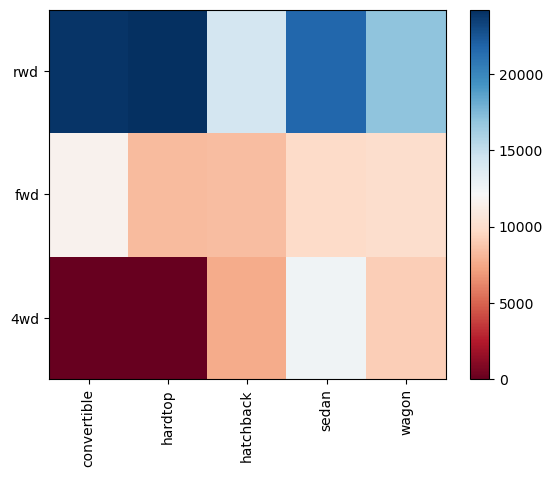

In [50]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

#label names
row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

#rotate label if too long
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

## Heatmap Interpretation

The heatmap reveals that rear-wheel-drive vehicles generally achieve higher average prices across multiple body styles. This suggests that drivetrain configuration contributes to pricing differences within the market.

Visualization is very important in data science, and Python visualization packages provide great freedom. We will go more in-depth in a separate Python visualizations course.

The main question we want to answer in this module is, "What are the main characteristics which have the most impact on the car price?".

To get a better measure of the important characteristics, we look at the correlation of these variables with the car price. In other words: how is the car price dependent on this variable?

## 5. Correlation and Causation

### Correlation: a measure of the extent of interdependence between variables.

### Causation: the relationship between cause and effect between two variables.

It is important to know the difference between these two. Correlation does not imply causation. Determining correlation is much simpler the determining causation as causation may require independent experimentation

### Pearson Correlation

The Pearson Correlation measures the linear dependence between two variables X and Y.

The resulting coefficient is a value between -1 and 1 inclusive, where:

1: Perfect positive linear correlation.
0: No linear correlation, the two variables most likely do not affect each other.
-1: Perfect negative linear correlation.
Pearson Correlation is the default method of the function "corr". Like before, we can calculate the Pearson Correlation of the of the 'int64' or 'float64' variables.

In [51]:
numeric_df=df._get_numeric_data()
numeric_df.corr()

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_L_100km,highway_L_100km,price,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.139987,-0.007654,-0.182196,0.075810,0.279740,0.066171,-0.029807,-0.082391,-0.196735,0.196735,0.054615,-0.054615
normalized_losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029846,0.055299,-0.114713,0.217300,0.239543,0.238567,0.181189,0.133999,-0.101546,0.101546,0.006911,-0.006911
wheel_base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493234,0.157851,0.250313,0.371178,-0.360305,0.476153,0.577576,0.584642,0.307237,-0.307237,-0.256889,0.256889
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608963,0.123830,0.159733,0.579795,-0.285970,0.657373,0.707108,0.690628,0.211187,-0.211187,-0.230085,0.230085
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544884,0.188796,0.189867,0.615056,-0.245800,0.673363,0.736728,0.751265,0.244356,-0.244356,-0.305732,0.305732
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180417,-0.061156,0.259737,-0.087001,-0.309974,0.003811,0.084301,0.135486,0.281578,-0.281578,-0.090336,0.090336
curb_weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644055,0.167357,0.156433,0.757981,-0.279361,0.785353,0.836921,0.834415,0.221046,-0.221046,-0.321955,0.321955
engine_size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572585,0.205549,0.028889,0.822668,-0.256733,0.745059,0.783465,0.872335,0.070779,-0.070779,-0.110040,0.110040
bore,-0.139987,-0.029846,0.493234,0.608963,0.544884,0.180417,0.644055,0.572585,1.000000,-0.055390,0.001260,0.566906,-0.267357,0.554640,0.559134,0.543155,0.054452,-0.054452,-0.227807,0.227807
stroke,-0.007654,0.055299,0.157851,0.123830,0.188796,-0.061156,0.167357,0.205549,-0.055390,1.000000,0.187816,0.098175,-0.063027,0.036601,0.047430,0.082262,0.240967,-0.240967,-0.218098,0.218098


In [52]:
import pandas as pd

# Keep only numeric data
numeric_df = df._get_numeric_data()

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Unstack to get all pairs and sort by absolute correlation
corr_pairs = corr_matrix.unstack()
# Remove self-correlation (correlation of a column with itself)
corr_pairs = corr_pairs[corr_pairs < 1]  
# Sort by absolute value descending
corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Show top 10 highest correlations
print(corr_pairs.head(10))


fuel-type-gas      fuel-type-diesel    -1.000000
fuel-type-diesel   fuel-type-gas       -1.000000
aspiration-turbo   aspiration-std      -1.000000
aspiration-std     aspiration-turbo    -1.000000
compression_ratio  fuel-type-diesel     0.985231
fuel-type-diesel   compression_ratio    0.985231
fuel-type-gas      compression_ratio   -0.985231
compression_ratio  fuel-type-gas       -0.985231
highway_L_100km    city_L_100km         0.958306
city_L_100km       highway_L_100km      0.958306
dtype: float64


Sometimes we would like to know the significant of the correlation estimate.

### P-value

What is this P-value? The P-value is the probability value that the correlation between these two variables is statistically significant. Normally, we choose a significance level of 0.05, which means that we are 95% confident that the correlation between the variables is significant.

By convention, when the

p-value is 
 0.001: we say there is strong evidence that the correlation is significant.
the p-value is 
 0.05: there is moderate evidence that the correlation is significant.
the p-value is 
 0.1: there is weak evidence that the correlation is significant.
the p-value is 
 0.1: there is no evidence that the correlation is significant.
We can obtain this information using "stats" module in the "scipy" library.



In [53]:
from scipy import stats

### Wheel-Base vs. Price


Let's calculate the Pearson Correlation Coefficient and P-value of 'wheel-base' and 'price'.

In [54]:
 df[['wheel_base', 'price']].corr()

,wheel_base,price
wheel_base,1.000000,0.584642
price,0.584642,1.000000


In [55]:
pearson_coef, p_value = stats.pearsonr(df['wheel_base'], df['price'])


print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)  

The Pearson Correlation Coefficient is 0.5846418222655081  with a P-value of P = 8.076488270732885e-20


In [56]:
print("The coeeficient and p value are:", stats.pearsonr(df['wheel_base'], df['price']), "respectively")

The coeeficient and p value are: PearsonRResult(statistic=np.float64(0.5846418222655081), pvalue=np.float64(8.076488270732885e-20)) respectively


### Conclusion:
Since the p-value is 
 0.001, the correlation between wheel-base and price is statistically significant, although the linear relationship isn't extremely strong (~0.585).

### Horsepower vs. Price

Let's calculate the Pearson Correlation Coefficient and P-value of 'horsepower' and 'price'.

In [57]:
pearson_coef, p_value = stats.pearsonr(df['horsepower'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.8096068016571054  with a P-value of P =  6.273536270650351e-48


### Numerical Insight

Horsepower shows a strong positive correlation with automobile price (r ≈ 0.81). The extremely small p-value (< 0.001) indicates that this relationship is statistically significant. Vehicles with greater horsepower generally command higher market prices.
 

### Length vs. Price
Let's calculate the Pearson Correlation Coefficient and P-value of 'length' and 'price'.

In [58]:
pearson_coef, p_value = stats.pearsonr(df['length'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.6906283810037583  with a P-value of P =  8.016476289929539e-30


In [59]:
### My Idea not too plain and well written
xy = df['length'].corr(df['price'])
pv = stats.pearsonr(df['length'], df['price'])
print("The Pearson Correlation Coefficient is", xy, " with a P-value of P = ", pv)  

The Pearson Correlation Coefficient is 0.6906283810037581  with a P-value of P =  PearsonRResult(statistic=np.float64(0.6906283810037583), pvalue=np.float64(8.016476289929539e-30))


### Conclusion:
Since the p-value is 
 0.001, the correlation between length and price is statistically significant, and the linear relationship is moderately strong (~0.691).

### Width vs. Price
Let's calculate the Pearson Correlation Coefficient and P-value of 'width' and 'price':

In [60]:
pearson_coef, p_value = stats.pearsonr(df['width'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value ) 

The Pearson Correlation Coefficient is 0.7512653454356579  with a P-value of P = 9.200331125592448e-38


### Numerical Insight

Vehicle width has a strong positive relationship with price (r ≈ 0.75). Wider vehicles generally belong to larger market segments and tend to have higher average selling prices.

### Curb-Weight vs. Price
Let's calculate the Pearson Correlation Coefficient and P-value of 'curb-weight' and 'price':

In [61]:
pearson_coef, p_value = stats.pearsonr(df['curb_weight'], df['price'])
print( "The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.8344145257702845  with a P-value of P =  2.189577238893965e-53


### Numerical Insight

Curb weight demonstrates a strong positive correlation with automobile price (r ≈ 0.83). Heavier vehicles tend to be more expensive, likely reflecting larger dimensions, more features, and higher-performance components.nt, and the linear relationship is quite strong (~0.834).



### Engine-Size vs. Price
Let's calculate the Pearson Correlation Coefficient and P-value of 'engine-size' and 'price':

In [62]:
pearson_coef, p_value = stats.pearsonr(df['engine_size'], df['price'])
print( "The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.8723351674455184  with a P-value of P =  9.265491622198793e-64


### Numerical Insight

Engine size exhibits one of the strongest relationships with automobile price (r ≈ 0.87). This suggests that larger engines are strongly associated with higher vehicle values, making engine size one of the most influential predictors of price.

### Bore vs. Price
Let's calculate the Pearson Correlation Coefficient and P-value of 'bore' and 'price':

In [63]:
pearson_coef, p_value = stats.pearsonr(df['bore'], df['price'])
print( "The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.5431549770315167  with a P-value of P =  8.049696658364881e-17


### Numerical Insight

Bore displays a moderate positive correlation with price (r ≈ 0.54). While engine bore contributes to engine performance characteristics, its influence on price is weaker than engine size and horsepower.

We can relate the process for each 'city_L_100km' and 'highway_L_100km':

### city_L_100km vs. Price

In [64]:
pearson_coef, p_value = stats.pearsonr(df['city_L_100km'], df['price'])
print( "The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.789897513762658  with a P-value of P =  3.9031062373673004e-44


### Conclusion:
Since the p-value is 
 0.001, the correlation between city_L_100km and price is statistically significant, and the coefficient of about 0.7898975

### highway_L_100km vs. Price

In [65]:
pearson_coef, p_value = stats.pearsonr(df['highway_L_100km'], df['price'])
print( "The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.8011176264553426  with a P-value of P =  3.0467845033397313e-46


### Conclusion:
Since the p-value is < 0.001, the correlation between highway-mpg and price is statistically significant, and the coefficient of about 0.801

## Findings from Correlation Analysis

- Engine Size showed one of the strongest positive correlations with price.
- Horsepower demonstrated a strong positive relationship with vehicle value.
- Curb Weight was strongly associated with higher prices.
- Fuel economy metrics showed meaningful relationships with pricing.
- Several vehicle dimensions also displayed statistically significant correlations.

## Correlation Findings Summary

Among all numerical variables examined, Engine Size (r ≈ 0.87), Curb Weight (r ≈ 0.83), and Horsepower (r ≈ 0.81) demonstrated the strongest relationships with automobile price. These features appear to be the most influential numerical predictors of vehicle value.

# 6. ANOVA

## ANOVA: Analysis of Variance
The Analysis of Variance (ANOVA) is a statistical method used to test whether there are significant differences between the means of two or more groups. ANOVA returns two parameters:

F-test score: ANOVA assumes the means of all groups are the same, calculates how much the actual means deviate from the assumption, and reports it as the F-test score. A larger score means there is a larger difference between the means.

P-value: P-value tells how statistically significant our calculated score value is.

If our price variable is strongly correlated with the variable we are analyzing, we expect ANOVA to return a sizeable F-test score and a small p-value.

## Drive Wheels
Since ANOVA analyzes the difference between different groups of the same variable, the groupby function will come in handy. Because the ANOVA algorithm averages the data automatically, we do not need to take the average before hand.

To see if different types of 'drive-wheels' impact 'price', we group the data.

In [66]:
grouped_test2=df_gptest[['drive_wheels', 'price']].groupby(['drive_wheels'])
grouped_test2.head(2)

,drive_wheels,price
0,rwd,13495
1,rwd,16500
3,fwd,13950
4,4wd,17450
5,fwd,15250
136,4wd,7603


In [67]:
df_gptest

,drive_wheels,body_style,price
0,rwd,convertible,13495
1,rwd,convertible,16500
2,rwd,hatchback,16500
3,fwd,sedan,13950
4,4wd,sedan,17450
...,...,...,...
196,rwd,sedan,16845
197,rwd,sedan,19045
198,rwd,sedan,21485
199,rwd,sedan,22470


We can obtain the values of the method group using the method "get_group".

In [68]:
grouped_test2.get_group('4wd')['price']

C:\Users\KHENNYG\AppData\Local\Temp\ipykernel_22032\4164424613.py:1: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  grouped_test2.get_group('4wd')['price']


4      17450
136     7603
140     9233
141    11259
144     8013
145    11694
150     7898
151     8778
Name: price, dtype: int64

We can use the function 'f_oneway' in the module 'stats' to obtain the F-test score and P-value.

In [69]:
# ANOVA
f_val, p_val = stats.f_oneway(grouped_test2.get_group('fwd')['price'], grouped_test2.get_group('rwd')['price'], grouped_test2.get_group('4wd')['price'])  
 
print( "ANOVA results: F=", f_val, ", P =", p_val)  

ANOVA results: F= 67.95406500780399 , P = 3.3945443577151245e-23


C:\Users\KHENNYG\AppData\Local\Temp\ipykernel_22032\2916034135.py:2: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  f_val, p_val = stats.f_oneway(grouped_test2.get_group('fwd')['price'], grouped_test2.get_group('rwd')['price'], grouped_test2.get_group('4wd')['price'])


This is a great result with a large F-test score showing a strong correlation and a P-value of almost 0 implying almost certain statistical significance. But does this mean all three tested groups are all this highly correlated?

Let's examine them separately

### fwd and rwd

In [70]:
f_val, p_val = stats.f_oneway(grouped_test2.get_group('fwd')['price'], grouped_test2.get_group('rwd')['price'])  
 
print( "ANOVA results: F=", f_val, ", P =", p_val )

ANOVA results: F= 130.55331609591104 , P = 2.235530635567824e-23


C:\Users\KHENNYG\AppData\Local\Temp\ipykernel_22032\1567334666.py:1: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  f_val, p_val = stats.f_oneway(grouped_test2.get_group('fwd')['price'], grouped_test2.get_group('rwd')['price'])


Let's examine the other groups.

### 4wd and rwd

In [71]:
f_val, p_val = stats.f_oneway(grouped_test2.get_group('4wd')['price'], grouped_test2.get_group('rwd')['price'])  
   
print( "ANOVA results: F=", f_val, ", P =", p_val)   

ANOVA results: F= 8.580681368924756 , P = 0.004411492211225333


C:\Users\KHENNYG\AppData\Local\Temp\ipykernel_22032\4057563169.py:1: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  f_val, p_val = stats.f_oneway(grouped_test2.get_group('4wd')['price'], grouped_test2.get_group('rwd')['price'])


### 4wd and fwd

In [72]:
f_val, p_val = stats.f_oneway(grouped_test2.get_group('4wd')['price'], grouped_test2.get_group('fwd')['price'])  
 
print("ANOVA results: F=", f_val, ", P =", p_val)   

ANOVA results: F= 0.665465750252303 , P = 0.41620116697845666


C:\Users\KHENNYG\AppData\Local\Temp\ipykernel_22032\472353397.py:1: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  f_val, p_val = stats.f_oneway(grouped_test2.get_group('4wd')['price'], grouped_test2.get_group('fwd')['price'])


We notice that ANOVA for the categories 4wd and fwd yields a high p-value > 0.1, so the calculated F-test score is not very statistically significant. This suggests we can't reject the assumption that the means of these two groups are the same, or, in other words, we can't conclude the difference in correlation to be significant.

## ANOVA Interpretation

The ANOVA results indicate statistically significant differences in vehicle prices across drive-wheel categories. Rear-wheel-drive vehicles tend to have higher average prices, while some comparisons involving four-wheel-drive vehicles show weaker statistical significance.

## Conclusion: Important Variables
We now have a better idea of what our data looks like and which variables are important to take into account when predicting the car price. We have narrowed it down to the following variables:

### Continuous numerical variables:
Length
Width
Curb-weight
Engine-size
Horsepower
City-mpg
Highway-mpg
Wheel-base
Bore

### Categorical variables:
Drive-wheels

## Key Findings

1. Engine Size showed one of the strongest positive relationships with vehicle price.
2. Horsepower demonstrated strong correlation with price.
3. Curb Weight was a significant pricing factor.
4. Fuel economy variables displayed inverse relationships with price.
5. Drive-Wheel configuration significantly influenced vehicle pricing.


These results indicate that engine characteristics and vehicle size are the strongest determinants of automobile price within the dataset.

# Final Conclusion

This analysis identified engine size, horsepower, curb weight, fuel economy metrics, and drive-wheel configuration as the most influential factors affecting automobile prices.

Through visualization, correlation analysis, and ANOVA testing, statistically significant relationships were established between several vehicle characteristics and market value. These findings provide a strong analytical foundation for future predictive modeling and machine learning applications focused on automobile price estimation.

